In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from PIL import Image
import os

from transformers import BertTokenizer, BertModel
from torchvision import models, transforms

In [2]:
DATASET_PATH = "/kaggle/input/notebooks/ditioza/fakeddit-dataset-download-preprocessing"

train_df = pd.read_csv(f"{DATASET_PATH}/train_final.tsv", sep='\t')
val_df   = pd.read_csv(f"{DATASET_PATH}/val_final.tsv", sep='\t')
test_df  = pd.read_csv(f"{DATASET_PATH}/test_final.tsv", sep='\t')

In [3]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

image_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
from PIL import Image

class MultiModalDataset(Dataset):
    def __init__(self, df):
        self.texts = df["clean_title"].tolist()
        self.labels = df["2_way_label"].tolist()
        self.image_paths = df["image_path"].tolist()
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        
        # Text
        encoding = tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=32,
            return_tensors='pt'
        )
        
        # Image (SAFE LOADING)
        img_path = os.path.join(DATASET_PATH, self.image_paths[idx])
        
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            image = Image.new("RGB", (224, 224))  # fallback
        
        image = image_transform(image)
        
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "image": image,
            "label": torch.tensor(label)
        }

In [5]:
train_loader = DataLoader(MultiModalDataset(train_df), batch_size=16, shuffle=True)
val_loader   = DataLoader(MultiModalDataset(val_df), batch_size=16)
test_loader  = DataLoader(MultiModalDataset(test_df), batch_size=16)

In [6]:
class MultiModalModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        # BERT
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        
        # ResNet
        self.resnet = models.resnet18(pretrained=True)
        self.resnet.fc = nn.Identity()  # remove classifier
        
        # Fusion
        self.fc = nn.Sequential(
            nn.Linear(768 + 512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, input_ids, attention_mask, image):
        # Text features
        text_out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        text_feat = text_out.pooler_output
        
        # Image features
        img_feat = self.resnet(image)
        
        # Combine
        combined = torch.cat((text_feat, img_feat), dim=1)
        
        return self.fc(combined)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiModalModel(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/mod

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


In [10]:
from sklearn.metrics import accuracy_score

def evaluate(loader):
    model.eval()
    preds, labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            images = batch["image"].to(device)
            y = batch["label"].cpu()
            
            out = model(input_ids, attention_mask, images)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(y.numpy())
    
    return accuracy_score(labels, preds)

In [11]:
best_val_acc = 0

for epoch in range(3):
    model.train()
    total_loss = 0   # ✅ track loss
    
    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        
        outputs = model(input_ids, attention_mask, images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()   # ✅ accumulate loss
    
    # ✅ evaluate after epoch
    val_acc = evaluate(val_loader)
    
    print(f"Epoch {epoch+1} | Loss: {total_loss:.2f} | Val Acc: {val_acc:.4f}")
    
    # ✅ SAVE BEST MODEL
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/kaggle/working/multimodal_best.pth")
        print("✅ Best model saved!")

Epoch 1 | Loss: 427.65 | Val Acc: 0.8546
✅ Best model saved!


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 2 | Loss: 216.70 | Val Acc: 0.8565
✅ Best model saved!


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 3 | Loss: 150.76 | Val Acc: 0.8475


In [12]:
train_acc = evaluate(train_loader)
val_acc   = evaluate(val_loader)
test_acc  = evaluate(test_loader)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Train Accuracy: 0.9964
Validation Accuracy: 0.8475
Test Accuracy: 0.8527


In [17]:
import matplotlib.pyplot as plt

label_map = {0: "Real", 1: "Fake"}

def predict(text, image_path):
    model.eval()
    
    # Text
    encoding = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=32,
        return_tensors='pt'
    )
    
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    
    # Image
    img = Image.open(image_path).convert("RGB")
    img_tensor = image_transform(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(input_ids, attention_mask, img_tensor)
        probs = torch.softmax(out, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()
    
    # Display results
    print("📝 Text:", text)
    print("🔮 Prediction:", label_map[pred])
    print(f"📊 Confidence: {confidence:.4f}")
    
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {label_map[pred]}")
    plt.show()
    
    return pred

📝 Text: me jumping in a big leaf pile
🔮 Prediction: Fake
📊 Confidence: 0.9986


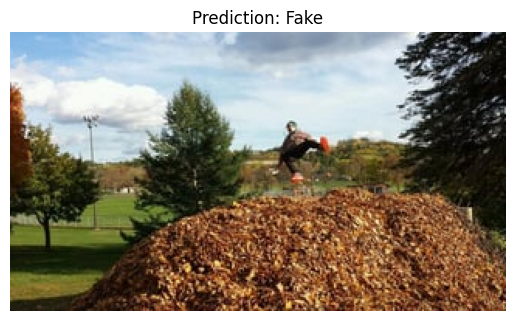

Prediction: 1


In [18]:
sample_img = f"{DATASET_PATH}/" + test_df["image_path"].iloc[0]
sample_text = test_df["clean_title"].iloc[0]

print("Prediction:", predict(sample_text, sample_img))

In [19]:
from sklearn.metrics import classification_report

model.eval()
preds, labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        images = batch["image"].to(device)
        y = batch["label"]
        
        out = model(input_ids, attention_mask, images)
        preds.extend(out.argmax(1).cpu().numpy())
        labels.extend(y.numpy())

print(classification_report(labels, preds))

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


              precision    recall  f1-score   support

           0       0.87      0.79      0.83      5976
           1       0.84      0.91      0.87      7377

    accuracy                           0.85     13353
   macro avg       0.86      0.85      0.85     13353
weighted avg       0.85      0.85      0.85     13353



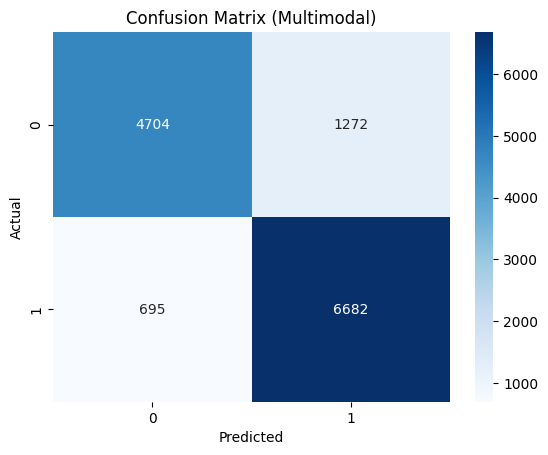

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Multimodal)")
plt.show()